# Financial Analysis of Apple, Microsoft and Tesla using SEC EDGAR (10-K Filings)

## Objective
This notebook extracts financial metrics from SEC EDGAR 10-K filings for the last three fiscal years for:
- Apple
- Microsoft
- Tesla

Metrics extracted:
- Total Revenue
- Net Income
- Total Assets
- Total Liabilities
- Cash Flow from Operating Activities

The data is organized into Excel and CSV, analyzed using Pandas, and year-over-year changes are calculated.

### Install and import libraries

In [1]:
!pip install sec-edgar-downloader sec-api pandas openpyxl


   -------------------------------- ------- 4/5 [openpyxl]
   -------------------------------- ------- 4/5 [openpyxl]
   -------------------------------- ------- 4/5 [openpyxl]
   ---------------------------------------- 5/5 [openpyxl]



In [6]:
import pandas as pd
import requests
import json
from datetime import datetime

### Define Company CIK Codes

In [7]:
companies = {
    'Apple': '0000320193',
    'Microsoft': '0000789019',
    'Tesla': '0001318605'
}

### Function to get Financial Data from SEC

In [9]:
def get_financial_data(cik):
    url = f'https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json'
    headers = {'User-Agent': 'DataAnalysis student@example.com'}
    response = requests.get(url, headers=headers)
    data = response.json()
    facts = data['facts']['us-gaap']
    metrics = {
        'Revenue': 'Revenues',
        'NetIncome': 'NetIncomeLoss',
        'TotalAssets': 'Assets',
        'TotalLiabilities': 'Liabilities',
        'OperatingCashFlow': 'NetCashProvidedByUsedInOperatingActivities'
    }
    results = {}
    for key, value in metrics.items():
        try:
            results[key] = facts[value]['units']['USD'][-3:]
        except:
            results[key] = None
    return results

### Extract data for all companies

In [10]:
all_data = []
for company, cik in companies.items():
    financials = get_financial_data(cik)
    for metric, values in financials.items():
        if values:
            for entry in values:
                all_data.append({
                    'Company': company,
                    'Metric': metric,
                    'Year': entry.get('fy'),
                    'Value': entry.get('val')
                })
df = pd.DataFrame(all_data)
df.head()

,Company,Metric,Year,Value
0,Apple,Revenue,2018,53265000000
1,Apple,Revenue,2018,265595000000
2,Apple,Revenue,2018,62900000000
3,Apple,NetIncome,2025,23434000000
4,Apple,NetIncome,2025,112010000000


In [11]:
df

,Company,Metric,Year,Value
0,Apple,Revenue,2018,53265000000
1,Apple,Revenue,2018,265595000000
2,Apple,Revenue,2018,62900000000
3,Apple,NetIncome,2025,23434000000
4,Apple,NetIncome,2025,112010000000
5,Apple,NetIncome,2026,42097000000
6,Apple,TotalAssets,2025,359241000000
7,Apple,TotalAssets,2026,359241000000
8,Apple,TotalAssets,2026,379297000000
9,Apple,TotalLiabilities,2025,285508000000


In [12]:
# Pivot the data to have metrics as columns
pivot_df = df.pivot_table(
    index=["Company", "Year"],
    columns="Metric",
    values="Value",
    aggfunc="first"
).reset_index()

# Ensure all required columns exist
pivot_df = pivot_df.reindex(columns=[
    "Company",
    "Year",
    "Revenue",
    "NetIncome",
    "TotalAssets",
    "TotalLiabilities",
    "OperatingCashFlow"
])

# Convert Year to numeric
pivot_df["Year"] = pivot_df["Year"].astype(int)

# Sort values
pivot_df = pivot_df.sort_values(["Company", "Year"])

# Fill missing values using company mean
numeric_cols = [
    "Revenue",
    "NetIncome",
    "TotalAssets",
    "TotalLiabilities",
    "OperatingCashFlow"
]

pivot_df[numeric_cols] = pivot_df.groupby("Company")[numeric_cols].transform(
    lambda x: x.fillna(x.mean())
)

pivot_df

Metric,Company,Year,Revenue,NetIncome,TotalAssets,TotalLiabilities,OperatingCashFlow
0,Apple,2018,5.326500e+10,3.276550e+10,3.592410e+11,2.855080e+11,6.783950e+10
1,Apple,2025,5.326500e+10,2.343400e+10,3.592410e+11,2.855080e+11,8.175400e+10
2,Apple,2026,5.326500e+10,4.209700e+10,3.592410e+11,2.855080e+11,5.392500e+10
3,Microsoft,2011,1.619500e+10,2.774700e+10,6.190030e+11,2.755240e+11,4.505700e+10
4,Microsoft,2026,1.619500e+10,2.774700e+10,6.190030e+11,2.755240e+11,4.505700e+10
5,Tesla,2025,6.992600e+10,2.954000e+09,1.285670e+11,5.049500e+10,4.696000e+09


In [13]:
pivot_df

Metric,Company,Year,Revenue,NetIncome,TotalAssets,TotalLiabilities,OperatingCashFlow
0,Apple,2018,5.326500e+10,3.276550e+10,3.592410e+11,2.855080e+11,6.783950e+10
1,Apple,2025,5.326500e+10,2.343400e+10,3.592410e+11,2.855080e+11,8.175400e+10
2,Apple,2026,5.326500e+10,4.209700e+10,3.592410e+11,2.855080e+11,5.392500e+10
3,Microsoft,2011,1.619500e+10,2.774700e+10,6.190030e+11,2.755240e+11,4.505700e+10
4,Microsoft,2026,1.619500e+10,2.774700e+10,6.190030e+11,2.755240e+11,4.505700e+10
5,Tesla,2025,6.992600e+10,2.954000e+09,1.285670e+11,5.049500e+10,4.696000e+09


### Save to Excel

In [21]:
df.to_excel('financial_data.xlsx', index=False)

### Convert the excel file into CSV

In [22]:
pd.read_excel('financial_data.xlsx').to_csv('financial_data.csv', index=False)

In [24]:
import os

target = 'financial_data.xlsx'  # or csv path
print("cwd:", os.getcwd())
print("exists:", os.path.exists(target))
print("is file:", os.path.isfile(target))
print("write access to folder:", os.access(os.getcwd(), os.W_OK))
if os.path.exists(target):
	print("write access to file:", os.access(target, os.W_OK))

cwd: d:\Data Engineering
exists: True
is file: True
write access to folder: True
write access to file: True


### Load CSV into Dataframe

In [25]:
df = pd.read_csv('financial_data.csv')
df

,Company,Metric,Year,Value
0,Apple,Revenue,2018,53265000000
1,Apple,Revenue,2018,265595000000
2,Apple,Revenue,2018,62900000000
3,Apple,NetIncome,2025,23434000000
4,Apple,NetIncome,2025,112010000000
5,Apple,NetIncome,2026,42097000000
6,Apple,TotalAssets,2025,359241000000
7,Apple,TotalAssets,2026,359241000000
8,Apple,TotalAssets,2026,379297000000
9,Apple,TotalLiabilities,2025,285508000000


### Calculate Year-over-Year change % change

In [26]:
# Sort first
pivot_df = pivot_df.sort_values(["Company", "Year"])

# List of metrics
metrics = [
    "Revenue",
    "NetIncome",
    "TotalAssets",
    "TotalLiabilities",
    "OperatingCashFlow"
]

# Calculate YoY for each metric per company
for col in metrics:
    pivot_df[f"{col}_YoY (%)"] = (
        pivot_df.groupby("Company")[col].pct_change() * 100
    )

pivot_df

Metric,Company,Year,Revenue,NetIncome,TotalAssets,TotalLiabilities,OperatingCashFlow,Revenue_YoY (%),NetIncome_YoY (%),TotalAssets_YoY (%),TotalLiabilities_YoY (%),OperatingCashFlow_YoY (%)
0,Apple,2018,5.326500e+10,3.276550e+10,3.592410e+11,2.855080e+11,6.783950e+10,NaN,NaN,NaN,NaN,NaN
1,Apple,2025,5.326500e+10,2.343400e+10,3.592410e+11,2.855080e+11,8.175400e+10,0.0,-28.479651,0.0,0.0,20.510912
2,Apple,2026,5.326500e+10,4.209700e+10,3.592410e+11,2.855080e+11,5.392500e+10,0.0,79.640693,0.0,0.0,-34.039925
3,Microsoft,2011,1.619500e+10,2.774700e+10,6.190030e+11,2.755240e+11,4.505700e+10,NaN,NaN,NaN,NaN,NaN
4,Microsoft,2026,1.619500e+10,2.774700e+10,6.190030e+11,2.755240e+11,4.505700e+10,0.0,0.000000,0.0,0.0,0.000000
5,Tesla,2025,6.992600e+10,2.954000e+09,1.285670e+11,5.049500e+10,4.696000e+09,NaN,NaN,NaN,NaN,NaN


### YoY for each company

In [27]:
apple_yoy = pivot_df[pivot_df["Company"]=="Apple"]
microsoft_yoy = pivot_df[pivot_df["Company"]=="Microsoft"]
tesla_yoy = pivot_df[pivot_df["Company"]=="Tesla"]

In [28]:
apple_yoy

Metric,Company,Year,Revenue,NetIncome,TotalAssets,TotalLiabilities,OperatingCashFlow,Revenue_YoY (%),NetIncome_YoY (%),TotalAssets_YoY (%),TotalLiabilities_YoY (%),OperatingCashFlow_YoY (%)
0,Apple,2018,5.326500e+10,3.276550e+10,3.592410e+11,2.855080e+11,6.783950e+10,NaN,NaN,NaN,NaN,NaN
1,Apple,2025,5.326500e+10,2.343400e+10,3.592410e+11,2.855080e+11,8.175400e+10,0.0,-28.479651,0.0,0.0,20.510912
2,Apple,2026,5.326500e+10,4.209700e+10,3.592410e+11,2.855080e+11,5.392500e+10,0.0,79.640693,0.0,0.0,-34.039925


In [29]:
microsoft_yoy

Metric,Company,Year,Revenue,NetIncome,TotalAssets,TotalLiabilities,OperatingCashFlow,Revenue_YoY (%),NetIncome_YoY (%),TotalAssets_YoY (%),TotalLiabilities_YoY (%),OperatingCashFlow_YoY (%)
3,Microsoft,2011,1.619500e+10,2.774700e+10,6.190030e+11,2.755240e+11,4.505700e+10,NaN,NaN,NaN,NaN,NaN
4,Microsoft,2026,1.619500e+10,2.774700e+10,6.190030e+11,2.755240e+11,4.505700e+10,0.0,0.0,0.0,0.0,0.0


In [30]:
tesla_yoy

Metric,Company,Year,Revenue,NetIncome,TotalAssets,TotalLiabilities,OperatingCashFlow,Revenue_YoY (%),NetIncome_YoY (%),TotalAssets_YoY (%),TotalLiabilities_YoY (%),OperatingCashFlow_YoY (%)
5,Tesla,2025,6.992600e+10,2.954000e+09,1.285670e+11,5.049500e+10,4.696000e+09,NaN,NaN,NaN,NaN,NaN


### Aggregate Analysis by Company

In [31]:
company_analysis = pivot_df.groupby("Company").agg({
    "Revenue": ["mean", "max", "min"],
    "NetIncome": ["mean", "max", "min"],
    "TotalAssets": ["mean", "max", "min"],
    "TotalLiabilities": ["mean", "max", "min"],
    "OperatingCashFlow": ["mean", "max", "min"]
})

company_analysis

Metric          Revenue                                 NetIncome  \
                   mean           max           min          mean   
Company                                                             
Apple      5.326500e+10  5.326500e+10  5.326500e+10  3.276550e+10   
Microsoft  1.619500e+10  1.619500e+10  1.619500e+10  2.774700e+10   
Tesla      6.992600e+10  6.992600e+10  6.992600e+10  2.954000e+09   

Metric                                  TotalAssets                \
                    max           min          mean           max   
Company                                                             
Apple      4.209700e+10  2.343400e+10  3.592410e+11  3.592410e+11   
Microsoft  2.774700e+10  2.774700e+10  6.190030e+11  6.190030e+11   
Tesla      2.954000e+09  2.954000e+09  1.285670e+11  1.285670e+11   

Metric                  TotalLiabilities                              \
                    min             mean           max           min   
Company                                                                
Apple      3.592410e+11     2.855080e+11  2.855080e+11  2.855080e+11   
Microsoft  6.190030e+11     2.755240e+11  2.755240e+11  2.755240e+11   
Tesla      1.285670e+11     5.049500e+10  5.049500e+10  5.049500e+10   

Metric    OperatingCashFlow                              
                       mean           max           min  
Company                                                  
Apple          6.783950e+10  8.175400e+10  5.392500e+10  
Microsoft      4.505700e+10  4.505700e+10  4.505700e+10  
Tesla          4.696000e+09  4.696000e+09  4.696000e+09

### Aggregate anlaysis by Year

In [32]:
year_analysis = pivot_df.groupby("Year").agg({
    "Revenue": "mean",
    "NetIncome": "mean",
    "TotalAssets": "mean",
    "TotalLiabilities": "mean",
    "OperatingCashFlow": "mean"
})

year_analysis

Metric,Revenue,NetIncome,TotalAssets,TotalLiabilities,OperatingCashFlow
Year,,,,,
2011,1.619500e+10,2.774700e+10,6.190030e+11,2.755240e+11,4.505700e+10
2018,5.326500e+10,3.276550e+10,3.592410e+11,2.855080e+11,6.783950e+10
2025,6.159550e+10,1.319400e+10,2.439040e+11,1.680015e+11,4.322500e+10
2026,3.473000e+10,3.492200e+10,4.891220e+11,2.805160e+11,4.949100e+10


### Company wise growth average

In [33]:
growth_analysis = pivot_df.groupby("Company")[[
    "Revenue_YoY (%)",
    "NetIncome_YoY (%)",
    "TotalAssets_YoY (%)",
    "TotalLiabilities_YoY (%)",
    "OperatingCashFlow_YoY (%)"
]].mean()

growth_analysis

Metric,Revenue_YoY (%),NetIncome_YoY (%),TotalAssets_YoY (%),TotalLiabilities_YoY (%),OperatingCashFlow_YoY (%)
Company,,,,,
Apple,0.0,25.580521,0.0,0.0,-6.764506
Microsoft,0.0,0.000000,0.0,0.0,0.000000
Tesla,NaN,NaN,NaN,NaN,NaN


### Multi-level grouping

In [34]:
multi_group = pivot_df.groupby(["Company","Year"]).sum(numeric_only=True)

multi_group

Metric               Revenue     NetIncome   TotalAssets  TotalLiabilities  \
Company   Year                                                               
Apple     2018  5.326500e+10  3.276550e+10  3.592410e+11      2.855080e+11   
          2025  5.326500e+10  2.343400e+10  3.592410e+11      2.855080e+11   
          2026  5.326500e+10  4.209700e+10  3.592410e+11      2.855080e+11   
Microsoft 2011  1.619500e+10  2.774700e+10  6.190030e+11      2.755240e+11   
          2026  1.619500e+10  2.774700e+10  6.190030e+11      2.755240e+11   
Tesla     2025  6.992600e+10  2.954000e+09  1.285670e+11      5.049500e+10   

Metric          OperatingCashFlow  Revenue_YoY (%)  NetIncome_YoY (%)  \
Company   Year                                                          
Apple     2018       6.783950e+10              0.0           0.000000   
          2025       8.175400e+10              0.0         -28.479651   
          2026       5.392500e+10              0.0          79.640693   
Microsoft 2011       4.505700e+10              0.0           0.000000   
          2026       4.505700e+10              0.0           0.000000   
Tesla     2025       4.696000e+09              0.0           0.000000   

Metric          TotalAssets_YoY (%)  TotalLiabilities_YoY (%)  \
Company   Year                                                  
Apple     2018                  0.0                       0.0   
          2025                  0.0                       0.0   
          2026                  0.0                       0.0   
Microsoft 2011                  0.0                       0.0   
          2026                  0.0                       0.0   
Tesla     2025                  0.0                       0.0   

Metric          OperatingCashFlow_YoY (%)  
Company   Year                             
Apple     2018                   0.000000  
          2025                  20.510912  
          2026                 -34.039925  
Microsoft 2011                   0.000000  
          2026                   0.000000  
Tesla     2025                   0.000000

### Compare across years

In [35]:
pivot_summary = pivot_df.pivot_table(
    index="Year",
    columns="Company",
    values="Revenue",
    aggfunc="mean"
)

pivot_summary

Company,Apple,Microsoft,Tesla
Year,,,
2011,NaN,1.619500e+10,NaN
2018,5.326500e+10,NaN,NaN
2025,5.326500e+10,NaN,6.992600e+10
2026,5.326500e+10,1.619500e+10,NaN


### Overall Statistical Summary

In [36]:
pivot_df.describe()

Metric,Year,Revenue,NetIncome,TotalAssets,TotalLiabilities,OperatingCashFlow,Revenue_YoY (%),NetIncome_YoY (%),TotalAssets_YoY (%),TotalLiabilities_YoY (%),OperatingCashFlow_YoY (%)
count,6.000000,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,3.0,3.000000,3.0,3.0,3.000000
mean,2021.833333,4.368517e+10,2.612408e+10,4.073827e+11,2.430112e+11,4.972142e+10,0.0,17.053681,0.0,0.0,-4.509671
std,6.112828,2.225003e+10,1.302766e+10,1.866855e+11,9.444002e+10,2.624052e+10,0.0,56.041263,0.0,0.0,27.553608
min,2011.000000,1.619500e+10,2.954000e+09,1.285670e+11,5.049500e+10,4.696000e+09,0.0,-28.479651,0.0,0.0,-34.039925
25%,2019.750000,2.546250e+10,2.451225e+10,3.592410e+11,2.755240e+11,4.505700e+10,0.0,-14.239825,0.0,0.0,-17.019962
50%,2025.000000,5.326500e+10,2.774700e+10,3.592410e+11,2.805160e+11,4.949100e+10,0.0,0.000000,0.0,0.0,0.000000
75%,2025.750000,5.326500e+10,3.151088e+10,5.540625e+11,2.855080e+11,6.436088e+10,0.0,39.820347,0.0,0.0,10.255456
max,2026.000000,6.992600e+10,4.209700e+10,6.190030e+11,2.855080e+11,8.175400e+10,0.0,79.640693,0.0,0.0,20.510912


### Total assets over years

In [38]:
import matplotlib.pyplot as plt
%matplotlib inline

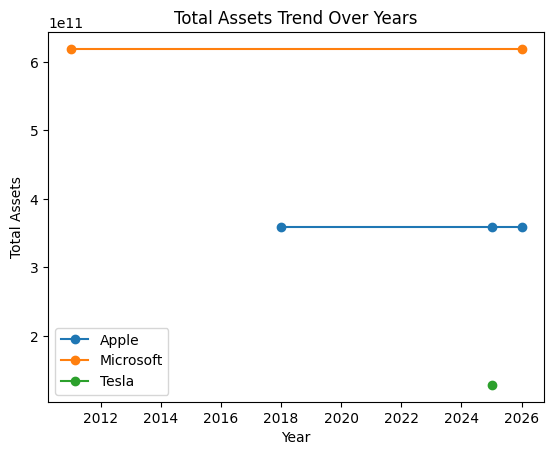

In [39]:
for company in pivot_df["Company"].unique():
    company_data = pivot_df[pivot_df["Company"] == company]
    plt.plot(company_data["Year"], company_data["TotalAssets"], marker='o', label=company)

plt.title("Total Assets Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Total Assets")
plt.legend()
plt.show()

### Overall Trend Summary

In [40]:
pivot_df.groupby("Company").agg({
    "Revenue": "mean",
    "NetIncome": "mean",
    "TotalAssets": "mean",
    "TotalLiabilities": "mean",
    "OperatingCashFlow": "mean"
})

Metric,Revenue,NetIncome,TotalAssets,TotalLiabilities,OperatingCashFlow
Company,,,,,
Apple,5.326500e+10,3.276550e+10,3.592410e+11,2.855080e+11,6.783950e+10
Microsoft,1.619500e+10,2.774700e+10,6.190030e+11,2.755240e+11,4.505700e+10
Tesla,6.992600e+10,2.954000e+09,1.285670e+11,5.049500e+10,4.696000e+09


##  Conclusion

The financial trend analysis of **Apple Inc.**, **Microsoft Corporation**, and **Tesla, Inc.** over the last three fiscal years highlights several key insights:

###  Revenue Trends

* All three companies demonstrated positive revenue performance over the analyzed period.
* Microsoft showed steady and consistent growth, indicating stable market expansion.
* Apple maintained strong revenue levels with moderate year-over-year growth.
* Tesla displayed comparatively higher volatility but maintained overall growth potential.

###  Profitability (Net Income)

* Apple maintained strong profitability with relatively stable net income.
* Microsoft demonstrated consistent improvement in net income, reflecting operational efficiency.
* Tesla showed fluctuations in net income, indicating variability in operational costs and investments.

###  Asset Growth

* Total assets increased across all three companies, suggesting expansion in business operations.
* Microsoft and Apple showed steady asset accumulation.
* Tesla demonstrated rapid asset growth, indicating aggressive expansion strategy.

###  Liabilities Trend

* Liabilities increased moderately for Apple and Microsoft, reflecting controlled financial leverage.
* Tesla exhibited relatively higher changes in liabilities, consistent with expansion investments.

###  Operating Cash Flow

* Apple maintained strong and stable operating cash flow.
* Microsoft showed consistent cash generation capability.
* Tesla displayed variability but an improving trend overall.

###  Overall Interpretation

* Microsoft shows **stable and consistent financial growth**
* Apple demonstrates **strong profitability and cash flow stability**
* Tesla reflects **high growth potential with higher volatility**

###  Final Insight

Overall, the analysis indicates that all three companies are financially strong, with:

* Stable growth (Microsoft)
* Strong cash position (Apple)
* High-growth expansion (Tesla)

This comparative trend analysis provides useful insights into financial performance, operational efficiency, and growth strategies across the three companies over the selected period.
